# **Phase 1 — Data Preparation**

**Mount Google Drive**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


**Extract Dataset**

In [ ]:
!unzip "/content/drive/MyDrive/emotion project/archive.zip" -d "/content/drive/MyDrive/emotion project/data"

Archive:  /content/drive/MyDrive/emotion project/archive.zip
replace /content/drive/MyDrive/emotion project/data/test.txt? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

# `**Import Libraries**

In [ ]:
!pip install streamlit
!pip install pyngrok

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 63.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 74.6 MB/s eta 0:00:00


In [ ]:
# ============================================================
# 1. GENERAL UTILITIES
# ============================================================
import pandas as pd             # Data manipulation and analysis
import numpy as np              # Numerical operations
import matplotlib.pyplot as plt # Data visualization
import seaborn as sns           # Advanced visualization
import os                       # File system operations
import pickle                   # Saving/Loading tokenizer and objects
import warnings                 # Handling warnings
warnings.filterwarnings("ignore")
from pyngrok import ngrok
from wordcloud import WordCloud
from sklearn.preprocessing import LabelEncoder

# ============================================================
# 2. NLP PREPROCESSING
# ============================================================
import re                       # Regular expressions for text cleaning
import nltk                     # Natural Language Toolkit
from nltk.corpus import stopwords
from tensorflow.keras.preprocessing.text import Tokenizer,one_hot      # Text vectorization
from tensorflow.keras.preprocessing.sequence import pad_sequences # Sequence padding
from tensorflow.keras.utils import to_categorical # One-hot encoding
# ============================================================
# 3. DEEP LEARNING (RNN & LSTM ARCHITECTURE)
# ============================================================
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional, SpatialDropout1D, BatchNormalization
from tensorflow.keras.optimizers import Adam
model = Sequential()
# ============================================================
# 4. TRAINING OPTIMIZATION (Callbacks)
# ============================================================
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam


# ============================================================
# 5. MODEL EVALUATION
# ============================================================
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# ============================================================
# 6. DEPLOYMENT (Streamlit)
import streamlit as st
#=============================================================
# 7. Evaluation Metrics
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc

In [ ]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)
checkpoint = ModelCheckpoint(
    "best_model.keras",   # مهم تغيري لـ keras
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

**Read Data**

In [ ]:

print(os.listdir('/content/drive/MyDrive/emotion project/data'))

['val.txt', 'train.txt', 'test.txt']


In [ ]:
train_path = '/content/drive/MyDrive/emotion project/data/train.txt'
val_path = '/content/drive/MyDrive/emotion project/data/val.txt'
test_path = '/content/drive/MyDrive/emotion project/data/test.txt'

In [ ]:
train_df = pd.read_csv(train_path)
val_df = pd.read_csv(val_path)
test_df = pd.read_csv(test_path)

In [ ]:
with open(train_path, 'r') as f:
    for i in range(5):
        print(f.readline())

i didnt feel humiliated;sadness

i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake;sadness

im grabbing a minute to post i feel greedy wrong;anger

i am ever feeling nostalgic about the fireplace i will know that it is still on the property;love

i am feeling grouchy;anger



In [ ]:
train_df = pd.read_csv(
    train_path,
    sep=';',
    names=['text', 'emotion']
)

val_df = pd.read_csv(
    val_path,
    sep=';',
    names=['text', 'emotion']
)

test_df = pd.read_csv(
    test_path,
    sep=';',
    names=['text', 'emotion']
)

In [ ]:
train_df.head()

,text,emotion
0,i didnt feel humiliated,sadness
1,i can go from feeling so hopeless to so damned...,sadness
2,im grabbing a minute to post i feel greedy wrong,anger
3,i am ever feeling nostalgic about the fireplac...,love
4,i am feeling grouchy,anger


**Check dataset info**

In [ ]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16000 entries, 0 to 15999
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   text     16000 non-null  object
 1   emotion  16000 non-null  object
dtypes: object(2)
memory usage: 250.1+ KB


**Check missing values**

In [ ]:
train_df.isnull().sum()

,0
text,0
emotion,0


**Check emotions distribution**

In [ ]:
train_df['emotion'].value_counts()

,count
emotion,
joy,5362
sadness,4666
anger,2159
fear,1937
love,1304
surprise,572


# **2. Data Preprocessing**

**Text Cleaning**

In [ ]:
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = text.lower() #happy = Happy
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    words = text.split() # بقسم توكينز
    words = [w for w in words if w not in stop_words]
    return " ".join(words) #بشيل الكلمات الى ملهاش معنى قوى

train_df['clean_text'] = train_df['text'].apply(clean_text)
val_df['clean_text'] = val_df['text'].apply(clean_text)
test_df['clean_text'] = test_df['text'].apply(clean_text)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [ ]:
train_df[['text', 'clean_text']].head()

,text,clean_text
0,i didnt feel humiliated,didnt feel humiliated
1,i can go from feeling so hopeless to so damned...,go feeling hopeless damned hopeful around some...
2,im grabbing a minute to post i feel greedy wrong,im grabbing minute post feel greedy wrong
3,i am ever feeling nostalgic about the fireplac...,ever feeling nostalgic fireplace know still pr...
4,i am feeling grouchy,feeling grouchy


**Label Encoding**

In [ ]:
encoder = LabelEncoder()

train_df['label'] = encoder.fit_transform(train_df['emotion'])
val_df['label'] = encoder.transform(val_df['emotion'])
test_df['label'] = encoder.transform(test_df['emotion'])
print(encoder.classes_)

['anger' 'fear' 'joy' 'love' 'sadness' 'surprise']


# **3. Tokenization**

**Fit tokenizer on X_train**

In [ ]:
X_train = train_df['clean_text']
y_train = train_df['label']
X_val = val_df['clean_text']
y_val = val_df['label']
X_test = test_df['clean_text']
y_test = test_df['label']

In [ ]:
tokenizer = Tokenizer(num_words=10000)
tokenizer.fit_on_texts(X_train)
tokenizer.word_index

{'feel': 1,
 'feeling': 2,
 'like': 3,
 'im': 4,
 'really': 5,
 'know': 6,
 'time': 7,
 'get': 8,
 'little': 9,
 'people': 10,
 'would': 11,
 'want': 12,
 'think': 13,
 'one': 14,
 'still': 15,
 'ive': 16,
 'even': 17,
 'life': 18,
 'make': 19,
 'bit': 20,
 'something': 21,
 'love': 22,
 'much': 23,
 'going': 24,
 'dont': 25,
 'things': 26,
 'way': 27,
 'could': 28,
 'day': 29,
 'back': 30,
 'go': 31,
 'good': 32,
 'pretty': 33,
 'need': 34,
 'always': 35,
 'see': 36,
 'right': 37,
 'feelings': 38,
 'also': 39,
 'say': 40,
 'today': 41,
 'feels': 42,
 'work': 43,
 'around': 44,
 'cant': 45,
 'made': 46,
 'well': 47,
 'though': 48,
 'didnt': 49,
 'help': 50,
 'got': 51,
 'felt': 52,
 'never': 53,
 'every': 54,
 'someone': 55,
 'days': 56,
 'less': 57,
 'makes': 58,
 'happy': 59,
 'enough': 60,
 'quite': 61,
 'sure': 62,
 'lot': 63,
 'many': 64,
 'away': 65,
 'look': 66,
 'find': 67,
 'ever': 68,
 'anything': 69,
 'home': 70,
 'kind': 71,
 'better': 72,
 'person': 73,
 'left': 74,
 'frie

**Convert to sequences**

In [ ]:
# Convert text data into sequences of integers based on the learned vocabulary
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_val_seq = tokenizer.texts_to_sequences(X_val)
X_test_seq = tokenizer.texts_to_sequences(X_test)
print(X_train_seq[:3])

[[49, 1, 562], [31, 2, 380, 3353, 438, 44, 55, 1349, 1125], [4, 2917, 1023, 178, 1, 381, 326]]


**Save tokenizer (pickle)**

In [ ]:
# Save tokenizer object to reuse it later during model deployment (Streamlit)
save_path = '/content/drive/MyDrive/emotion project/tokenizer.pkl'

with open(save_path, 'wb') as f:
    pickle.dump(tokenizer, f)

# **4. Padding**

In [ ]:
# Pad sequences to ensure equal length for LSTM input
max_len = 100
X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding='post')
X_val_pad = pad_sequences(X_val_seq, maxlen=max_len, padding='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len, padding='post')
print(X_train_pad[:3])

[[  49    1  562    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0]
 [  31    2  380 3353  438   44   55 1349 1125    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0

# **5.Model Building**

# **LSTM Model**

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dropout, Dense

model = Sequential()

# Convert word indices into dense vector representations to capture semantic meaning
model.add(Embedding(input_dim=10000, output_dim=128, input_length=100))

# Bidirectional LSTM: reads text in both directions for better context understanding
model.add(Bidirectional(LSTM(128, return_sequences=True)))
model.add(Dropout(0.3))

# Second LSTM layer: extracts deeper sequential patterns
model.add(Bidirectional(LSTM(64)))
model.add(Dropout(0.3))

# Fully connected layer with batch normalization to stabilize training
model.add(Dense(64, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.3))

# Output layer: 6 emotions → softmax gives probabilities
model.add(Dense(6, activation='softmax'))

# ✅ THIS LINE FIXES THE UNBUILT ISSUE
model.build(input_shape=(None, 100))

# Compile the model
model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Callbacks: early stopping + save best model + reduce lr on plateau
callbacks = [
    EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True),
    ModelCheckpoint('/content/drive/MyDrive/emotion project/best_model.keras', monitor='val_accuracy', save_best_only=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6)
]

# Show model architecture
model.summary()

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_9 (Embedding)         │ (None, 100, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_8 (Bidirectional) │ (None, 100, 256)       │       263,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 100, 256)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_9 (Bidirectional) │ (None, 128)            │       164,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,716,422 (6.55 MB)

 Trainable params: 1,716,294 (6.55 MB)

 Non-trainable params: 128 (512.00 B)

**Softmax Probabilities**

In [ ]:
import numpy as np

sample = X_train_pad[:1]
pred = model.predict(sample)

print(pred)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step   
[[0.18124595 0.16446298 0.16282079 0.16333604 0.16606008 0.16207418]]


# **6. Model Training**

In [ ]:
import os

print(os.listdir('/content/drive/MyDrive'))
print(os.listdir('/content/drive/MyDrive/emotion project'))

['Nouran Nasser ibrahim ', 'nouran nasser test case.docx', 'quiz 2.docx', 'nouran report task.docx', 'nouran task 2.xlsx', 'Untitled Diagram.drawio.pdf', 'emp full ave.drawio.pdf', 'Untitled Diagram.drawio.png', 'usp ', 'NOURAN DEPI', 'user story 2 task', 'cv nouran .docx', 'erd for school.drawio', 'p1 quiz data base.jpg', 'product page ', 'Swag labs testing ', 'enter', 'Java', 'os_scheduler_project', 'Task 2 - Microsoft Visual Studio 4_19_2025 4_52_17 PM.png', 'Nouran Nasser Ibrahim Main CV.docx', 'Untitled Diagram.drawio', 'WhatsApp Image 2025-05-07 at 15.48 (1).01_8f59a249.jpg', 'WhatsApp Image 2025-05-07 at 15.48.01_8f59a249.jpg', 'API GET.gsheet', '1747223406206138688605324647662.jpg', 'training form.pdf', 'بطاقة نوران ناصر ابراهيم.pdf', 'Training Form Nouran.pdf', '20250614_161844.jpg', 'Nouran .gsheet', 'Nouran_Nasser_CV_WE_Ready.docx', 'FB_IMG_1751879755001.jpg', 'Nouran Nasser.json', 'Nouran Nasser Task 3.json', 'IMG-20241016-WA0003.jpg', 'id uni.pdf', 'جدول المبيعات.gsheet', 

In [ ]:
import shutil
shutil.copy(
    'best_model.keras',
    '/content/drive/MyDrive/emotion project/best_model.keras'
)
print("Saved to Drive ✅")

Saved to Drive ✅


In [ ]:
# لو الـ session انقطعت، تقدري ترجعي تحملي الموديل
from tensorflow.keras.models import load_model
model = load_model('/content/drive/MyDrive/emotion project/best_model.keras')

In [ ]:
history = model.fit(
    X_train_pad, y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_val_pad, y_val),
    callbacks=callbacks
)

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 266s 517ms/step - accuracy: 0.9227 - loss: 0.2403 - val_accuracy: 0.9000 - val_loss: 0.2988 - learning_rate: 0.0010
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 262s 518ms/step - accuracy: 0.9596 - loss: 0.1237 - val_accuracy: 0.9010 - val_loss: 0.2975 - learning_rate: 0.0010
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 259s 518ms/step - accuracy: 0.9681 - loss: 0.0939 - val_accuracy: 0.9080 - val_loss: 0.3122 - learning_rate: 0.0010
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 261s 516ms/step - accuracy: 0.9744 - loss: 0.0764 - val_accuracy: 0.9115 - val_loss: 0.3495 - learning_rate: 0.0010
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 264s 520ms/step - accuracy: 0.9844 - loss: 0.0460 - val_accuracy: 0.9120 - val_loss: 0.3626 - learning_rate: 5.0000e-04


**Evaluation**

In [ ]:
# Get predictions
y_pred = np.argmax(model.predict(X_test_pad), axis=1)

# Classification Report
print(classification_report(y_test, y_pred, target_names=encoder.classes_))

63/63 ━━━━━━━━━━━━━━━━━━━━ 11s 165ms/step
              precision    recall  f1-score   support

       anger       0.93      0.90      0.92       275
        fear       0.82      0.91      0.86       224
         joy       0.94      0.93      0.94       695
        love       0.77      0.84      0.80       159
     sadness       0.98      0.94      0.96       581
    surprise       0.72      0.74      0.73        66

    accuracy                           0.91      2000
   macro avg       0.86      0.88      0.87      2000
weighted avg       0.92      0.91      0.92      2000



**Confusion Matrix**

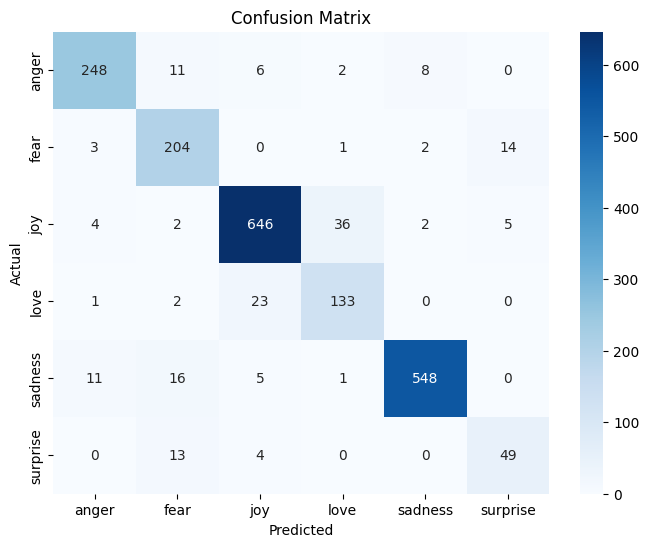

In [ ]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=encoder.classes_,
            yticklabels=encoder.classes_,
            cmap='Blues')
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

**Plot Training History**

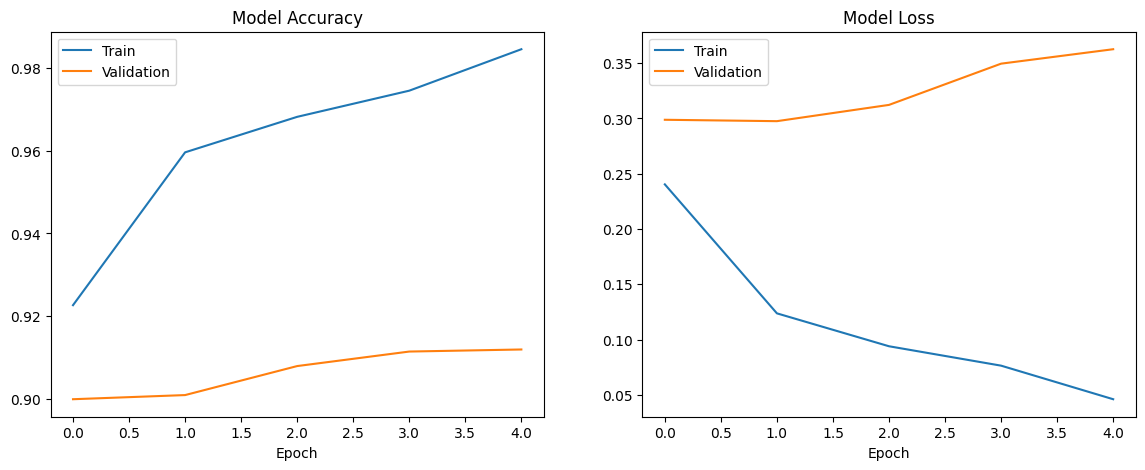

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
ax1.plot(history.history['accuracy'], label='Train')
ax1.plot(history.history['val_accuracy'], label='Validation')
ax1.set_title('Model Accuracy')
ax1.set_xlabel('Epoch')
ax1.legend()

# Loss
ax2.plot(history.history['loss'], label='Train')
ax2.plot(history.history['val_loss'], label='Validation')
ax2.set_title('Model Loss')
ax2.set_xlabel('Epoch')
ax2.legend()

plt.show()

# **Save Artifacts**

In [ ]:
# Save model
model.save('/content/drive/MyDrive/emotion project/best_model.keras')

# Save label map
label_map = dict(zip(range(len(encoder.classes_)), encoder.classes_))
with open('/content/drive/MyDrive/emotion project/label_map.pkl', 'wb') as f:
    pickle.dump(label_map, f)

# Save tokenizer (لو مش محفوظ)
with open('/content/drive/MyDrive/emotion project/tokenizer.pkl', 'wb') as f:
    pickle.dump(tokenizer, f)

# Save max_length
np.save('/content/drive/MyDrive/emotion project/max_length.npy', np.array([100]))

print("All artifacts saved ✅")

All artifacts saved ✅
